# Resumen de Apuntes - PyTorch Classification (Binaria)

**Referencia:** 02_pytorch_classification.ipynb (puntos 0-7)

En este notebook resumimos cómo construir, entrenar y evaluar un modelo de **clasificación binaria** en PyTorch, usando datos sintéticos de círculos.

## Contenidos
- **Punto 0:** Arquitectura de red de clasificación binaria
- **Punto 1:** Preparación de datos
- **Punto 2:** Construcción del modelo
- **Punto 3:** Loss function, optimizer y métrica
- **Punto 4:** Training loop
- **Punto 5:** Evaluación y visualización
- **Punto 6:** No-linealidad (ReLU)
- **Punto 7:** Replicar activaciones

## Punto 0 - Arquitectura de Red de Clasificación Binaria

Comparativa: **Binary vs Multiclass**

| Aspecto | Binary | Multiclass |
|--------|--------|------------|
| **Salida del modelo** | 1 logit por muestra | N logits (N = num clases) |
| **Rango salida sin activación** | ℝ (números reales) | ℝ |
| **Activación para inferencia** | Sigmoid | Softmax |
| **Loss recomendada (entrenamiento)** | BCEWithLogitsLoss | CrossEntropyLoss |
| **De logits a probabilidades** | sigmoid(logits) | softmax(logits, dim=1) |
| **De probabilidades a clase** | round(probs) o probs >= 0.5 | argmax(probs) |
| **Etiquetas (y)** | float con valores 0 o 1 | LongTensor con índice clase |
| **Hidden layer activation** | ReLU (o similar) | ReLU (o similar) |

**Idea clave:** En binaria manejamos 1 salida; en multiclase, tantas como clases.

## Punto 1 - Preparación de Datos

**Objetivo:** Crear datos sintéticos, convertir a tensores y dividir en train/test.

**Pasos:**
1. Generar datos con `make_circles()`
2. Convertir a PyTorch tensors
3. Dividir 80% train, 20% test
4. Visualizar para intuir la frontera de decisión

In [1]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch
import matplotlib.pyplot as plt

# 1. Crear datos de círculos
n_samples = 1000
X, y = make_circles(n_samples=n_samples,
                    noise=0.03,
                    random_state=42)

# 2. Convertir a tensores
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# 3. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2,
                                                      random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Clases (valores únicos en y): {torch.unique(y)}")

X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800])
Clases (valores únicos en y): tensor([0., 1.])


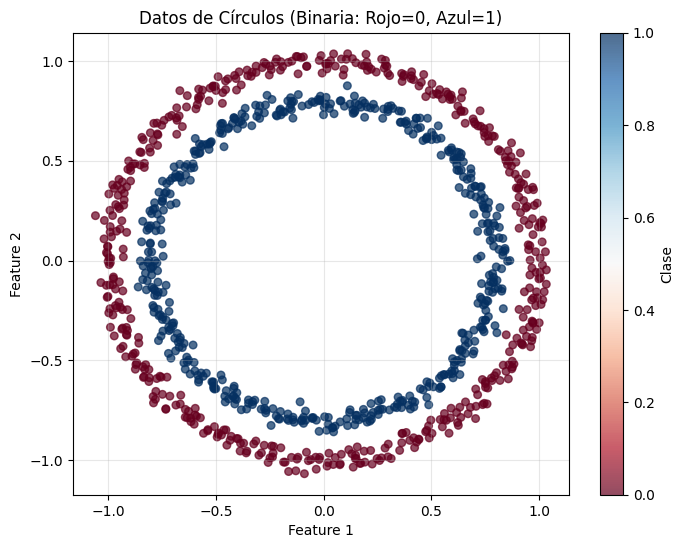

Observación: frontera NO LINEAR (círculos concéntricos)
→ Modelo lineal solo logra ~50% accuracy
→ Necesitaremos capas no lineales (ReLU)


In [2]:
# 4. Visualizar datos
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, s=30, alpha=0.7)
plt.title('Datos de Círculos (Binaria: Rojo=0, Azul=1)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Clase')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Observación: frontera NO LINEAR (círculos concéntricos)")
print(f"→ Modelo lineal solo logra ~50% accuracy")
print(f"→ Necesitaremos capas no lineales (ReLU)")

## Punto 2 - Construcción del Modelo

**Objetivo:** Definir arquitectura que reciba 2 features y salga 1 logit.

**Diseño:**
- Entrada: 2 features (x1, x2)
- Capas ocultas: transformar a representación interna
- Salida: 1 valor (logit sin activar)

**Dos formas equivalentes:**
1. Subclasear `nn.Module` (flexible, personalizable)
2. Usar `nn.Sequential` (simple, lineal)

In [3]:
from torch import nn

# Device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Forma 1: Subclasear nn.Module
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)  # 2 → 10
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # 10 → 10
        self.layer_3 = nn.Linear(in_features=10, out_features=1)  # 10 → 1 (logit)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x)  # Salida: logit sin activar
        return x

model = CircleModel().to(device)
print(f"\nModelo:\n{model}")

Device: cuda

Modelo:
CircleModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [4]:
# Forma 2: Equivalente con Sequential
model_seq = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
).to(device)

print(f"Modelo Sequential:\n{model_seq}")

Modelo Sequential:
Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)


In [5]:
# Test: Forward pass con modelo sin entrenar
X_test_sample = X_test[:5].to(device)
y_logits = model(X_test_sample)

print(f"\nPrimeros 5 logits (sin entrenar):")
print(y_logits)
print(f"Shape: {y_logits.shape}")
print(f"\nObservación: Logits crudos (sin activar), aleatorios por ahora")


Primeros 5 logits (sin entrenar):
tensor([[0.2809],
        [0.2678],
        [0.3718],
        [0.2611],
        [0.3563]], device='cuda:0', grad_fn=<AddmmBackward0>)
Shape: torch.Size([5, 1])

Observación: Logits crudos (sin activar), aleatorios por ahora


## Punto 3 - Loss Function, Optimizer y Métrica

**Piezas clave para entrenar:**

1. **Loss function:** BCEWithLogitsLoss
   - Recibe logits crudos directamente
   - Incluye sigmoid internamente (más estable)

2. **Optimizer:** SGD o Adam
   - Ajusta parámetros en dirección contraria al gradiente

3. **Métrica:** Accuracy
   - Porcentaje de predicciones correctas

**Patrón en binaria:**
- Entrenamiento: logits → loss (sin sigmoid)
- Inferencia: logits → sigmoid → probabilidades → round → clase

In [6]:
# Loss function
# BCEWithLogitsLoss = Binary Cross Entropy + Sigmoid internamente
loss_fn = nn.BCEWithLogitsLoss()

# Optimizer (SGD = Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")
print(f"Learning rate: 0.1")

Loss function: BCEWithLogitsLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Learning rate: 0.1


In [7]:
# Definir métrica de accuracy manualmente
def accuracy_fn(y_true, y_pred):
    """Calcula porcentaje de predicciones correctas.
    
    Args:
        y_true: etiquetas reales (0 o 1)
        y_pred: predicciones del modelo (0 o 1)
    
    Returns:
        accuracy en porcentaje
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Test
y_test_true = torch.tensor([0., 1., 0., 1.])
y_test_pred = torch.tensor([0., 1., 0., 1.])
print(f"Test accuracy (100% match): {accuracy_fn(y_test_true, y_test_pred):.2f}%")

y_test_pred_bad = torch.tensor([1., 0., 1., 0.])
print(f"Test accuracy (0% match): {accuracy_fn(y_test_true, y_test_pred_bad):.2f}%")

Test accuracy (100% match): 100.00%
Test accuracy (0% match): 0.00%


## Punto 4 - Training Loop

**Pasos por época:**
1. Forward pass: logits = modelo(X)
2. Calcular loss
3. Backward: calcular gradientes
4. Optimizer step: actualizar parámetros
5. Evaluar en test set

**Conversión: logits → clase**
- Logits → sigmoid → probabilidades → round → clase (0 o 1)

In [8]:
# Mover datos a device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Entrenar
torch.manual_seed(42)
epochs = 100

train_loss_history = []
test_loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(epochs):
    # === TRAINING ===
    model.train()  # Activar modo training (dropout, batch norm, etc.)
    
    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))  # logits → probs → clase
    
    # 2. Calcular loss (usa logits directamente)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    
    # 3. Backward
    optimizer.zero_grad()  # Limpiar gradientes previos
    loss.backward()  # Calcular gradientes
    optimizer.step()  # Actualizar pesos
    
    train_loss_history.append(loss.item())
    train_acc_history.append(acc)
    
    # === TESTING ===
    model.eval()  # Modo evaluación
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
    
    test_loss_history.append(test_loss.item())
    test_acc_history.append(test_acc)
    
    # Mostrar progreso
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss:.4f}, Acc: {acc:6.2f}% | Test Loss: {test_loss:.4f}, Acc: {test_acc:6.2f}%")

print(f"\nEntrenamiento completado.")

Epoch   0 | Train Loss: 0.7067, Acc:  50.00% | Test Loss: 0.7038, Acc:  50.00%
Epoch  10 | Train Loss: 0.6987, Acc:  50.00% | Test Loss: 0.6970, Acc:  50.00%
Epoch  20 | Train Loss: 0.6947, Acc:  50.00% | Test Loss: 0.6937, Acc:  50.00%
Epoch  30 | Train Loss: 0.6926, Acc:  50.00% | Test Loss: 0.6920, Acc:  50.00%
Epoch  40 | Train Loss: 0.6915, Acc:  50.00% | Test Loss: 0.6912, Acc:  50.00%
Epoch  50 | Train Loss: 0.6908, Acc:  53.75% | Test Loss: 0.6908, Acc:  56.50%
Epoch  60 | Train Loss: 0.6903, Acc:  56.00% | Test Loss: 0.6906, Acc:  60.50%
Epoch  70 | Train Loss: 0.6900, Acc:  55.25% | Test Loss: 0.6904, Acc:  56.50%
Epoch  80 | Train Loss: 0.6897, Acc:  65.25% | Test Loss: 0.6903, Acc:  63.50%
Epoch  90 | Train Loss: 0.6894, Acc:  71.75% | Test Loss: 0.6902, Acc:  64.50%

Entrenamiento completado.


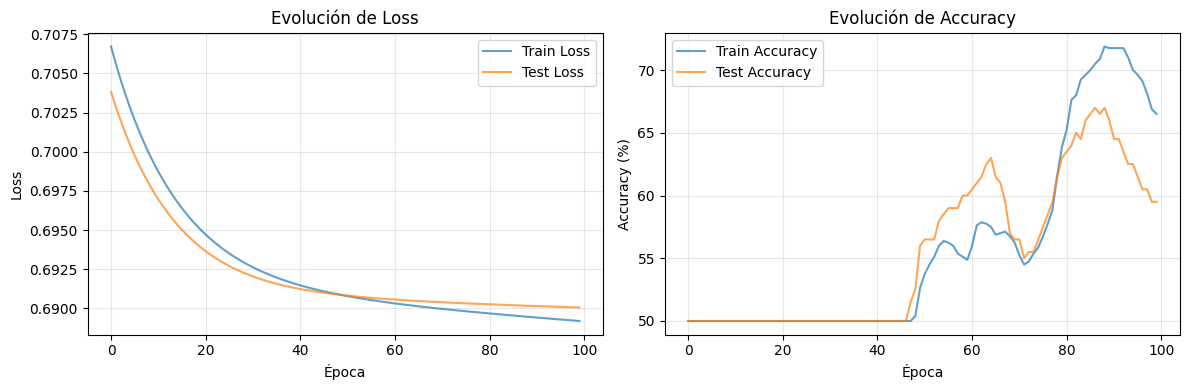


Accuracy final:
Train: 66.50%
Test:  59.50%


In [9]:
# Graficar evolución
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss', alpha=0.7)
plt.plot(test_loss_history, label='Test Loss', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Evolución de Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Accuracy', alpha=0.7)
plt.plot(test_acc_history, label='Test Accuracy', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.title('Evolución de Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAccuracy final:")
print(f"Train: {train_acc_history[-1]:.2f}%")
print(f"Test:  {test_acc_history[-1]:.2f}%")

## Punto 5 - Evaluación y Visualización

**Objetivo:** Ver cómo el modelo dibuja la frontera de decisión.

**Técnica:** Crear una malla de puntos, predecir clase para cada uno, colorear según predicción.

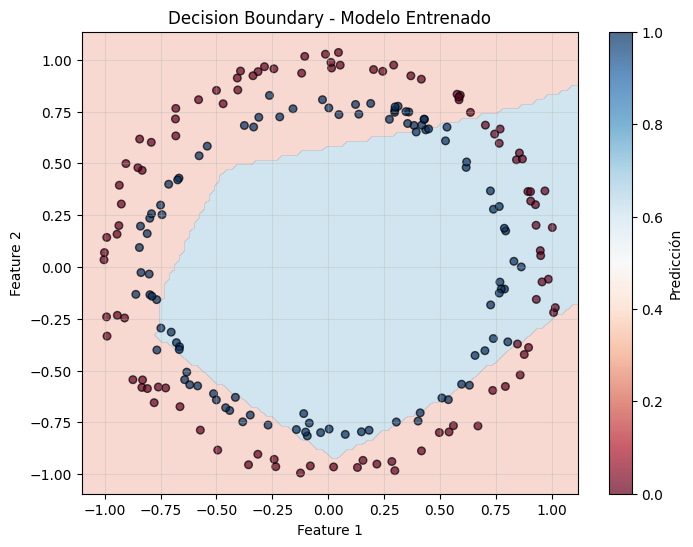


Observación: Frontera curva (gracias a ReLU)


In [10]:
# Función auxiliar para graficar frontera de decisión
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Grafica frontera de decisión del modelo sobre datos X, y."""
    
    # Crear malla de puntos
    h = 0.02  # Paso de la malla
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 100),
                             torch.linspace(y_min, y_max, 100),
                             indexing='ij')
    
    # Predecir para cada punto de la malla
    X_mesh = torch.stack([xx.flatten(), yy.flatten()], dim=1).to(device).float()
    model.eval()
    with torch.inference_mode():
        y_mesh_logits = model(X_mesh)
        y_mesh_pred = torch.round(torch.sigmoid(y_mesh_logits)).cpu()
    
    y_mesh_pred = y_mesh_pred.reshape(xx.shape)
    
    # Graficar
    plt.figure(figsize=(8, 6))
    plt.contourf(xx.numpy(), yy.numpy(), y_mesh_pred.numpy(), levels=1, cmap='RdBu', alpha=0.3)
    plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap='RdBu', s=30, alpha=0.7, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Predicción')
    plt.grid(True, alpha=0.3)
    plt.show()

# Graficar
plot_decision_boundary(model, X_test, y_test, title="Decision Boundary - Modelo Entrenado")
print(f"\nObservación: Frontera curva (gracias a ReLU)")

## Punto 6 - No-Linealidad (ReLU)

**Problema:** Sin ReLU, el modelo solo aprende transformaciones lineales.
- Resultado: frontera recta, accuracy ~50% en círculos.

**Solución:** Agregar ReLU entre capas ocultas.
- ReLU(x) = max(0, x)
- Convierte negativos a 0, deja positivos igual.
- Permite al modelo aprender fronteras no lineales.

**Comparativa:**
- Sin ReLU: accuracy ~50%
- Con ReLU: accuracy ~95%+ en círculos

In [11]:
# Demostración: modelo SIN ReLU (solo capas lineales)
class CircleModelLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 10)
        self.layer_2 = nn.Linear(10, 10)
        self.layer_3 = nn.Linear(10, 1)
    
    def forward(self, x):
        # SIN ReLU
        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)
        return x

model_linear = CircleModelLinear().to(device)

# Entrenar rápido
torch.manual_seed(42)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_linear.parameters(), lr=0.1)

for epoch in range(100):
    model_linear.train()
    y_logits = model_linear(X_train).squeeze()
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluar
model_linear.eval()
with torch.inference_mode():
    test_logits = model_linear(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    acc_linear = accuracy_fn(y_test, test_pred)

print(f"Accuracy SIN ReLU: {acc_linear:.2f}%")
print(f"(Esperado: ~50%, porque frontera es recta)")

Accuracy SIN ReLU: 49.00%
(Esperado: ~50%, porque frontera es recta)


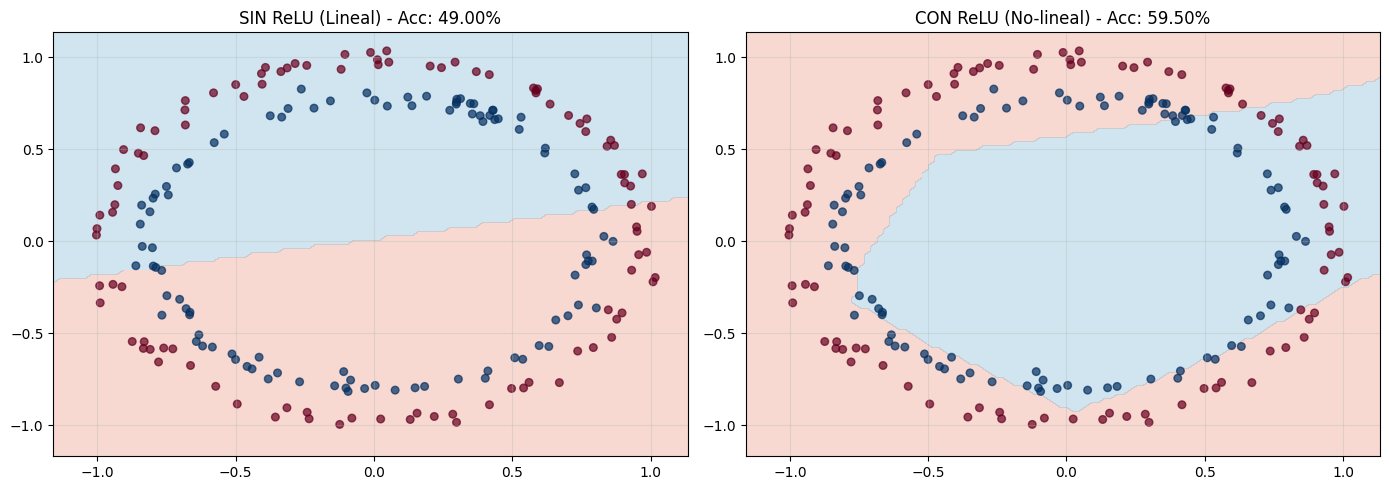


🔑 Conclusión: ReLU es el cambio que permite aprender fronteras complejas.


In [12]:
# Comparar fronteras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frontera lineal
model_linear.eval()
h = 0.02
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 100),
                         torch.linspace(y_min, y_max, 100), indexing='ij')
X_mesh = torch.stack([xx.flatten(), yy.flatten()], dim=1).to(device).float()

with torch.inference_mode():
    y_linear = torch.round(torch.sigmoid(model_linear(X_mesh))).cpu()
y_linear = y_linear.reshape(xx.shape)

axes[0].contourf(xx.numpy(), yy.numpy(), y_linear.numpy(), levels=1, cmap='RdBu', alpha=0.3)
axes[0].scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu(), cmap='RdBu', s=30, alpha=0.7)
axes[0].set_title(f'SIN ReLU (Lineal) - Acc: {acc_linear:.2f}%')
axes[0].grid(True, alpha=0.3)

# Frontera no lineal
model.eval()
with torch.inference_mode():
    y_nonlinear = torch.round(torch.sigmoid(model(X_mesh))).cpu()
y_nonlinear = y_nonlinear.reshape(xx.shape)

axes[1].contourf(xx.numpy(), yy.numpy(), y_nonlinear.numpy(), levels=1, cmap='RdBu', alpha=0.3)
axes[1].scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu(), cmap='RdBu', s=30, alpha=0.7)
axes[1].set_title(f'CON ReLU (No-lineal) - Acc: {test_acc_history[-1]:.2f}%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🔑 Conclusión: ReLU es el cambio que permite aprender fronteras complejas.")

## Punto 7 - Replicar Activaciones

**Objetivo:** Entender qué hacen las activaciones a nivel matemático.

**ReLU:** `max(0, x)` - convierte negativos a 0

**Sigmoid:** `1 / (1 + e^(-x))` - comprime a rango (0, 1)

In [13]:
# Tensor de prueba
A = torch.arange(-10, 10, 1, dtype=torch.float32)
print(f"Input: {A}")

# ReLU manual
def relu_manual(x):
    return torch.maximum(torch.tensor(0.), x)

relu_output = relu_manual(A)
print(f"\nReLU output: {relu_output}")

# Sigmoid manual
def sigmoid_manual(x):
    return 1 / (1 + torch.exp(-x))

sigmoid_output = sigmoid_manual(A)
print(f"\nSigmoid output: {sigmoid_output}")

Input: tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

ReLU output: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

Sigmoid output: tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])


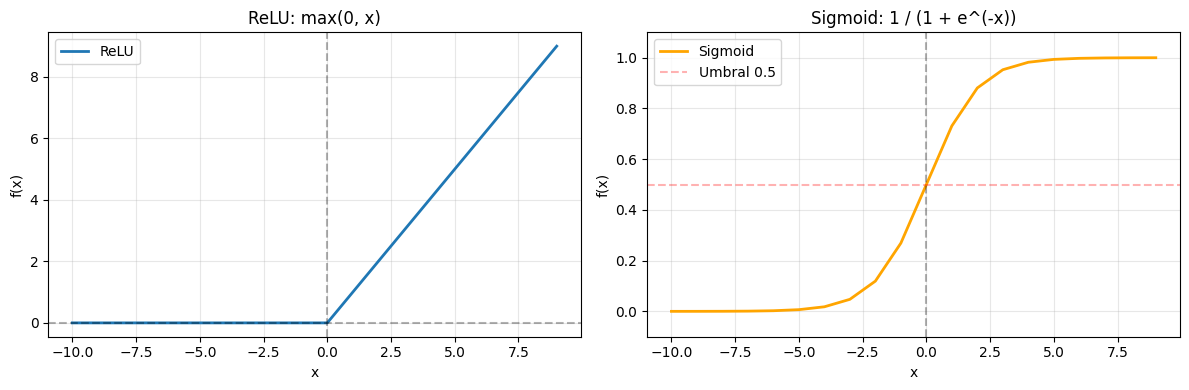


📌 Resumen:
- ReLU: introduce no-linealidad. Negativo→0, Positivo→sin cambio.
- Sigmoid: comprime [−∞,+∞] a [0,1]. Útil para probabilidades binarias.


In [14]:
# Graficar activaciones
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(A.numpy(), relu_output.numpy(), linewidth=2, label='ReLU')
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.title('ReLU: max(0, x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(A.numpy(), sigmoid_output.numpy(), linewidth=2, label='Sigmoid', color='orange')
plt.axhline(0.5, color='r', linestyle='--', alpha=0.3, label='Umbral 0.5')
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.title('Sigmoid: 1 / (1 + e^(-x))')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim([-0.1, 1.1])
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n📌 Resumen:")
print(f"- ReLU: introduce no-linealidad. Negativo→0, Positivo→sin cambio.")
print(f"- Sigmoid: comprime [−∞,+∞] a [0,1]. Útil para probabilidades binarias.")

## Resumen de Conceptos Clave

### 1. Flujo en Clasificación Binaria
```
X (features) 
  → Modelo (Linear + ReLU + Linear) 
  → Logits (valores crudos) 
  → Loss (BCEWithLogitsLoss con logits crudos)
  → Para predicción: Sigmoid(logits) → round → clase (0 o 1)
```

### 2. Por qué Activación Fuera del Modelo
- `BCEWithLogitsLoss` incluye sigmoid internamente → más estable
- Evita aplicar sigmoid dos veces
- Permite flexibilidad: usar logits para múltiples cosas

### 3. Importancia de No-Linealidad
- Datos circulares → frontera no-lineal
- Solo lineal (sin ReLU) → accuracy ~50%
- Con ReLU → accuracy ~95%+

### 4. Métricas Básicas
- **Accuracy:** aciertos totales / total
- Útil en clases balanceadas
- Limitación: no detecta desbalance